In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load processed data
client_data = pd.read_csv('../data/processed/client_analysis_data.csv')
trades = pd.read_csv('../data/processed/trades_processed.csv')
transactions = pd.read_csv('../data/processed/transactions_processed.csv')

#convert date columns
client_data['join_date'] = pd.to_datetime(client_data['join_date'])
trades['transaction_date'] = pd.to_datetime(trades['transaction_date'])
transactions['date'] = pd.to_datetime(transactions['date'])

# --- dataset preview ---
print("\n🔎 Dataset Previews:")
print("Client Data:")
display(client_data.head())
print("Trades:")
display(trades.head())
print("Transactions:")
display(transactions.head())


🔎 Dataset Previews:
Client Data:


,client_id,age,income_bracket,risk_tolerance,investment_experience,join_date,country,tenure_days,account_balance,last_updated,...,total_trade_value,avg_trade_value,std_trade_value,total_quantity,avg_quantity,total_transaction_value,transaction_count,deposit_ratio,avg_daily_trades,value_per_trade
0,C10000,54,Medium,Very High,Beginner,2020-02-16,Canada,2040,11119,2025-09-16 18:10:22.208536,...,2070146.74,20496.50,14622.27,10030,99.31,52091.0,10,0.80,0.049510,20496.502376
1,C10001,61,Medium,Low,Beginner,2025-11-15,Canada,-59,27182,2025-09-16 18:10:22.214717,...,2466664.64,25170.05,18070.90,10828,110.49,27182.0,1,1.00,98.000000,25170.047347
2,C10002,27,Medium,Very High,Intermediate,2024-08-17,Germany,396,46465,2025-09-16 18:10:22.216712,...,2056016.16,22593.58,16463.27,9686,106.44,46815.0,2,0.50,0.229798,22593.584176
3,C10003,23,Low,Very High,Intermediate,2022-02-03,Germany,1322,25315,2025-09-16 18:10:22.217713,...,1998764.47,21725.70,17154.08,9172,99.70,34596.0,3,0.67,0.069592,21725.700761
4,C10004,57,Medium,High,Advanced,2025-11-07,Australia,-51,21668,2025-09-16 18:10:22.218707,...,1841425.29,19383.42,15530.80,8619,90.73,21668.0,1,1.00,95.000000,19383.424105


Trades:


,transaction_id,client_id,symbol,transaction_date,type,quantity,price,amount,transaction_month,transaction_week
0,T100000,C10298,MSFT,2025-05-04,Buy,192,278.68,53505.91,2025-05,18
1,T100001,C10720,AMZN,2024-10-19,Sell,37,132.04,4885.52,2024-10,42
2,T100002,C10720,NVDA,2025-08-21,Sell,60,335.72,20143.46,2025-08,34
3,T100003,C10968,AMZN,2025-12-11,Sell,167,107.63,17974.13,2025-12,50
4,T100004,C10254,TSLA,2020-11-29,Buy,88,172.50,15180.05,2020-11,48


Transactions:


,client_id,date,type,amount,transaction_month
0,C10000,2020-02-16,Deposit,11119.0,2020-02
1,C10000,2021-08-12,Withdrawal,2118.0,2021-08
2,C10000,2024-04-10,Withdrawal,3869.0,2024-04
3,C10000,2021-06-03,Deposit,175.0,2021-06
4,C10000,2024-12-19,Deposit,5174.0,2024-12


In [3]:
#dataset shapes and info
print("\n📊 Dataset Shapes:")
print(f"Client Data: {client_data.shape}")
print(f"Trades: {trades.shape}")
print(f"Transactions: {transactions.shape}")

print("\nℹ️ Client Data Info:")
client_data.info()
print("\nℹ️ Trades Info:")
trades.info()
print("\nℹ️ Transactions Info:")
transactions.info()


📊 Dataset Shapes:
Client Data: (1000, 21)
Trades: (100000, 10)
Transactions: (5515, 5)

ℹ️ Client Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   client_id                1000 non-null   object        
 1   age                      1000 non-null   int64         
 2   income_bracket           1000 non-null   object        
 3   risk_tolerance           1000 non-null   object        
 4   investment_experience    1000 non-null   object        
 5   join_date                1000 non-null   datetime64[ns]
 6   country                  1000 non-null   object        
 7   tenure_days              1000 non-null   int64         
 8   account_balance          1000 non-null   int64         
 9   last_updated             1000 non-null   object        
 10  trade_count              1000 non-null   int64 

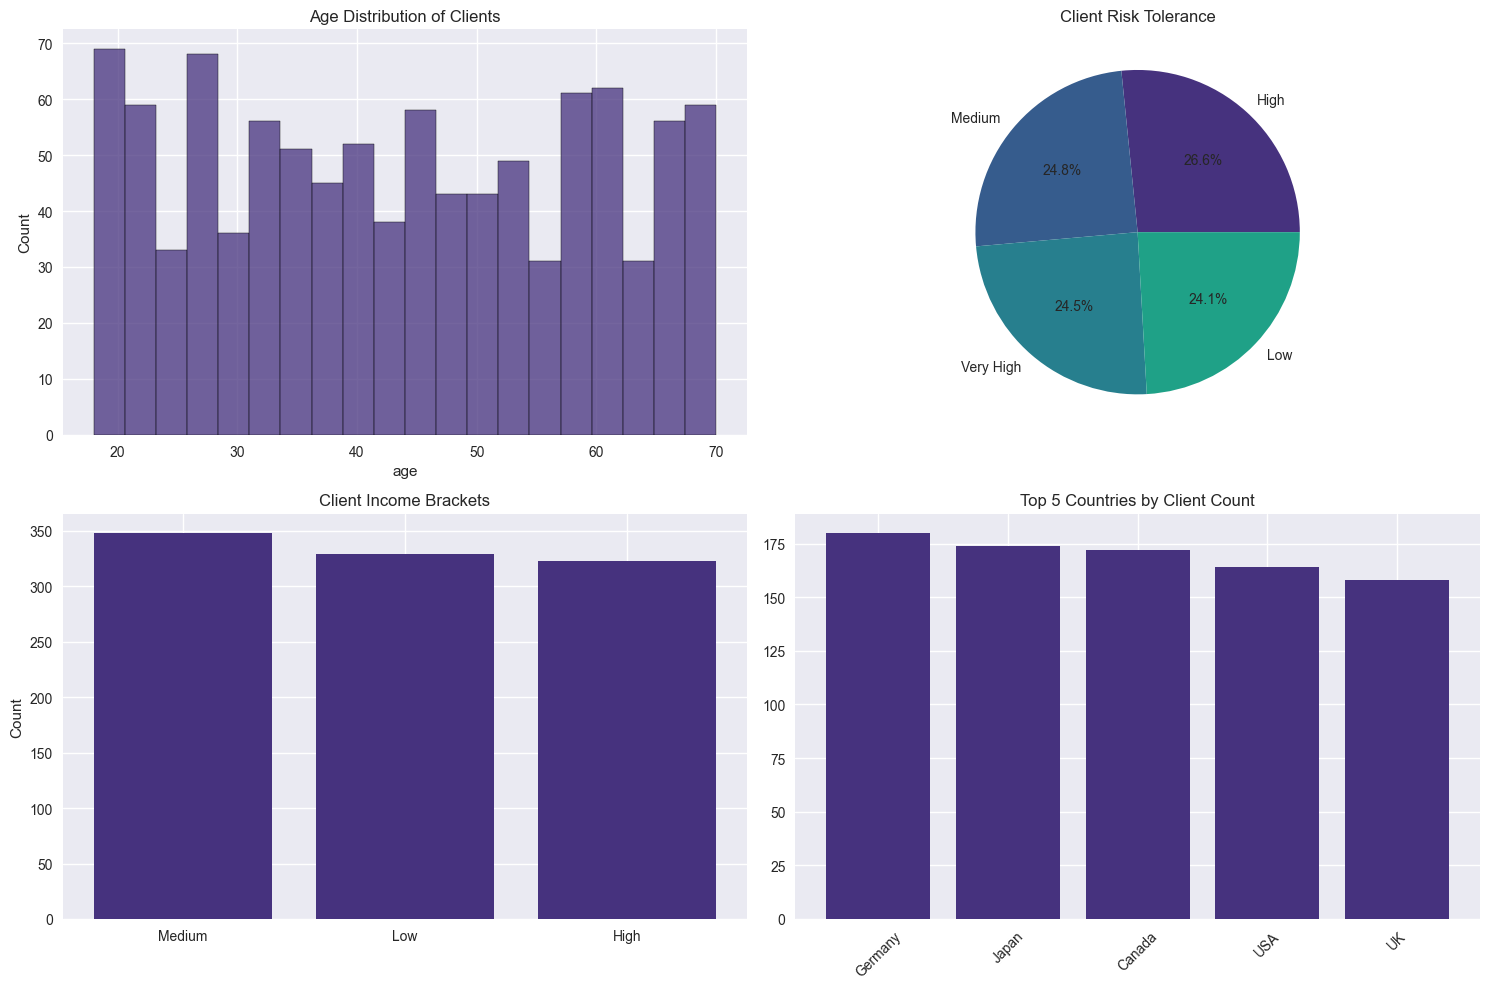

In [4]:
#set style
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')

#1. client demographic
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#age distribution
sns.histplot(data=client_data, x='age', bins=20, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution of Clients')

#risk tolerance
risk_counts = client_data['risk_tolerance'].value_counts()
axes[0, 1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%')
axes[0, 1].set_title('Client Risk Tolerance')

#income distribution
income_counts = client_data['income_bracket'].value_counts()
axes[1, 0].bar(income_counts.index, income_counts.values)
axes[1, 0].set_title('Client Income Brackets')
axes[1, 0].set_ylabel('Count')

#country distribution
country_counts = client_data['country'].value_counts().head(5)
axes[1, 1].bar(country_counts.index, country_counts.values)
axes[1, 1].set_title('Top 5 Countries by Client Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/client_demographics.png', dpi=300, bbox_inches='tight')
plt.show()

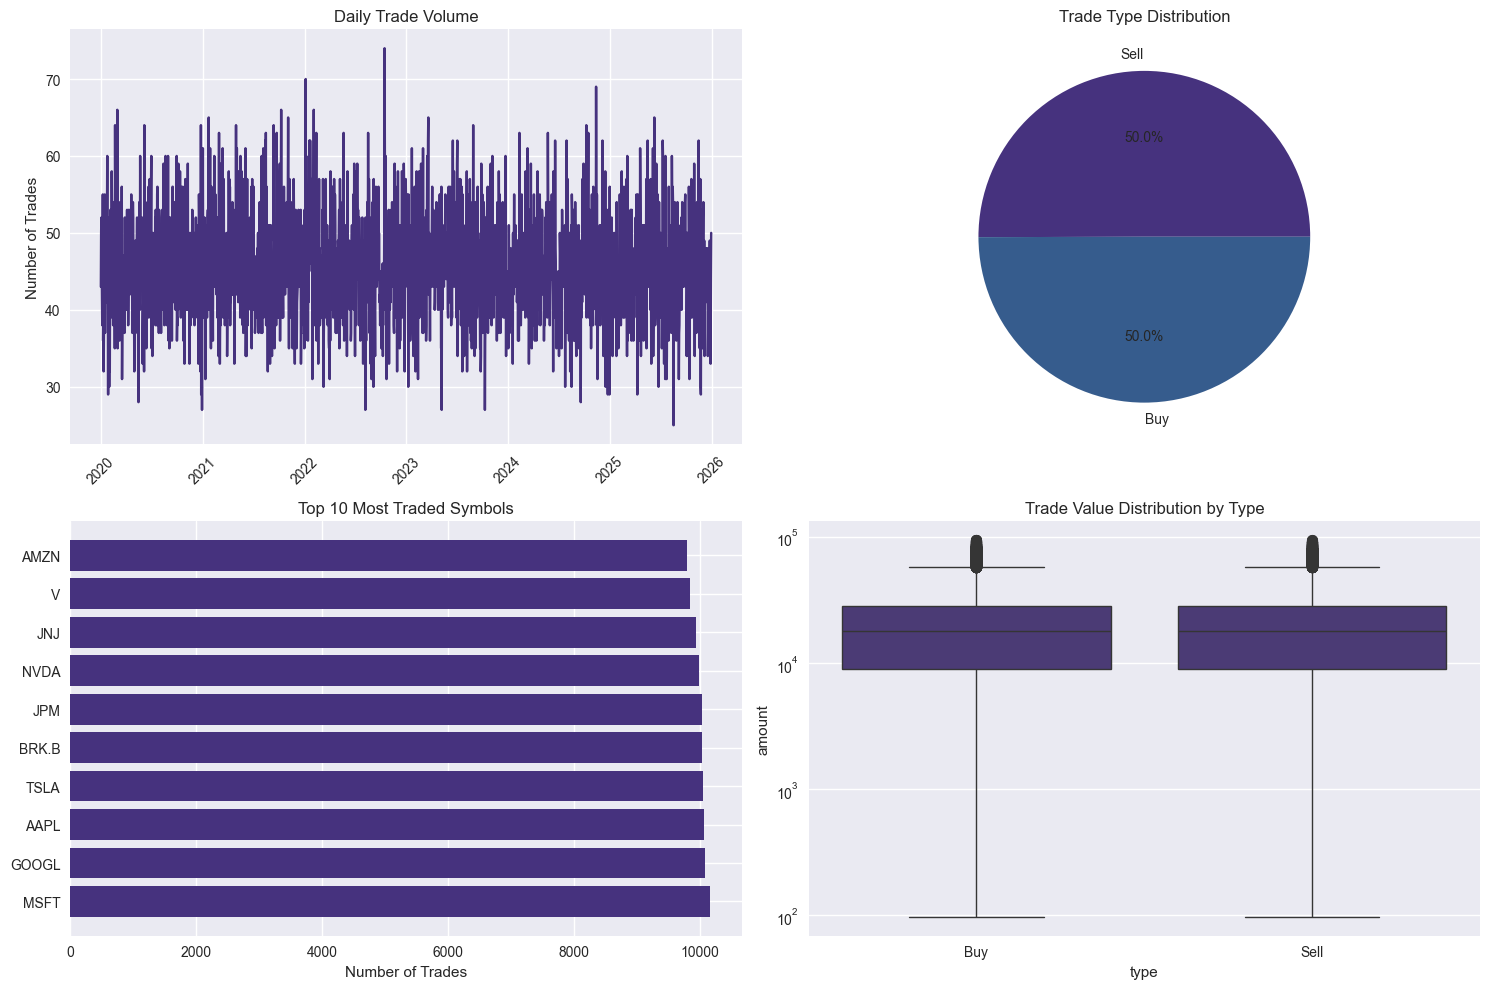

In [5]:
#2. trading behaviour analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#trade volume over time
trade_daily = trades.groupby(trades['transaction_date'].dt.date).size()
axes[0, 0].plot(trade_daily.index, trade_daily.values)
axes[0, 0].set_title('Daily Trade Volume')
axes[0, 0].set_ylabel('Number of Trades')
axes[0, 0].tick_params(axis='x', rotation=45)

#trade type distribution
trade_type = trades['type'].value_counts()
axes[0, 1].pie(trade_type.values, labels=trade_type.index, autopct='%1.1f%%')
axes[0, 1].set_title('Trade Type Distribution')

#most traded symbols
top_symbols = trades['symbol'].value_counts().head(10)
axes[1, 0].barh(top_symbols.index, top_symbols.values)
axes[1, 0].set_title('Top 10 Most Traded Symbols')
axes[1, 0].set_xlabel('Number of Trades')

#trade value distribution
sns.boxplot(data=trades, x='type', y='amount', ax=axes[1, 1])
axes[1, 1].set_title('Trade Value Distribution by Type')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('../reports/trading_behavior.png', dpi=300, bbox_inches='tight')
plt.show()

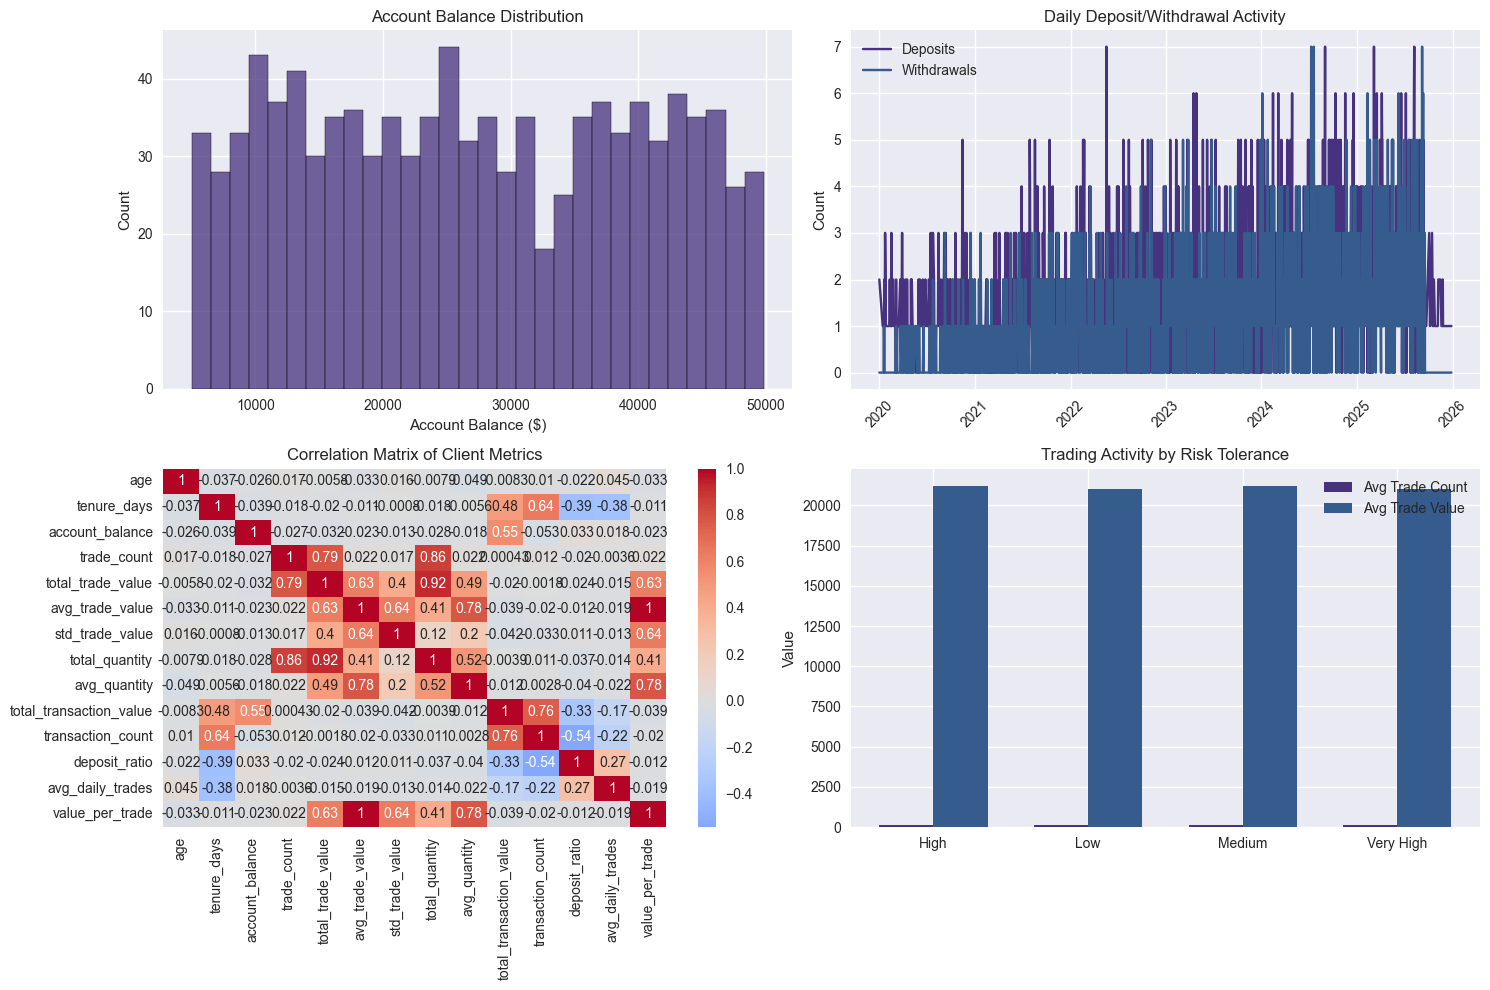

In [6]:
#3. financial patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#account balance distribution
sns.histplot(data=client_data, x='account_balance', bins=30, ax=axes[0, 0])
axes[0, 0].set_title('Account Balance Distribution')
axes[0, 0].set_xlabel('Account Balance ($)')

#transaction patterns
transaction_daily = transactions.groupby([transactions['date'].dt.date, 'type']).size().unstack(fill_value=0)
axes[0, 1].plot(transaction_daily.index, transaction_daily['Deposit'], label='Deposits')
axes[0, 1].plot(transaction_daily.index, transaction_daily['Withdrawal'], label='Withdrawals')
axes[0, 1].set_title('Daily Deposit/Withdrawal Activity')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

#correlation heatmap
numeric_cols = client_data.select_dtypes(include=[np.number]).columns
corr_matrix = client_data[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix of Client Metrics')

#risk tolerance vs trading activity
risk_trade = client_data.groupby('risk_tolerance').agg({
    'trade_count': 'mean',
    'avg_trade_value': 'mean'
}).reset_index()
x = np.arange(len(risk_trade))
width = 0.35
axes[1, 1].bar(x - width/2, risk_trade['trade_count'], width, label='Avg Trade Count')
axes[1, 1].bar(x + width/2, risk_trade['avg_trade_value'], width, label='Avg Trade Value')
axes[1, 1].set_title('Trading Activity by Risk Tolerance')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(risk_trade['risk_tolerance'])
axes[1, 1].legend()
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../reports/financial_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
#interactive visualisations with plotly
#client geographical distribution
country_counts = client_data['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']
fig = px.choropleth(country_counts, 
                    locations='country', 
                    locationmode='country names',
                    color='count', 
                    title='Client Geographical Distribution')
fig.write_html('../reports/geo_distribution.html')

#trading volume over time
trade_monthly = trades.groupby(trades['transaction_date'].dt.to_period('M')).size().reset_index()
trade_monthly.columns = ['month', 'count']
trade_monthly['month'] = trade_monthly['month'].astype(str)
fig = px.line(trade_monthly, x='month', y='count', title='Monthly Trading Volume')
fig.write_html('../reports/monthly_trading.html')

print("\n🎉 EDA and visualizations completed!")


🎉 EDA and visualizations completed!
